# 1. Problem Definition & Data Assembly

### 1.1. Problem Definition

The goal of this project is to build and train a model that accurately classifies handwritten digits from the MNIST dataset. This is a **multiclass classification problem**. The model will be built using Dense and Dropout layers, adhering to the principles outlined in Chapters 1-4 of "Deep Learning with Python" (DLWP).

*   **Input Data:** The input data consists of grayscale images of handwritten digits. Each image is 28x28 pixels, with pixel values ranging from 0 to 255.
*   **Output Data:** The output is a classification of the input image into one of ten classes, representing the digits 0 through 9.

### 1.2. Data Description

The MNIST dataset consists of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is grayscale and 28x28 pixels in size. The task is a multiclass classification problem, where the model must assign each image to one of ten classes (the digits 0 through 9). The dataset is conveniently available through the Keras API.

In [1]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)
print("Train labels:", train_labels)

2025-03-10 01:37:27.783723: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-10 01:37:27.784282: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 01:37:27.786391: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 01:37:27.792338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741541847.801888   96299 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741541847.80

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Train labels: [5 0 4 ... 5 6 8]


### 1.3. Data Hypotheses

*   **Hypothesis 1:** The output (digit class) can be predicted from the input (pixel values of the image).  This is a reasonable hypothesis given the nature of the MNIST dataset, as the pixel patterns in the images are visually indicative of the digit being represented.
*   **Hypothesis 2:** The available data is informative enough to learn the relationship between the inputs and outputs.  The MNIST dataset is sufficiently large and well-structured for a deep learning model to learn the underlying patterns.

### 1.4. Environment Setup

This section outlines the necessary libraries and dependencies required to execute the code in this notebook.

*   **Python:** Version 3.6 or higher
*   **TensorFlow:** Version 2.0 or higher (with Keras API)
*   **NumPy:** For numerical operations

In [2]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.18.0
NumPy version: 2.0.2


### 1.5. Data Loading and Exploration

Here, we load the MNIST dataset using the Keras API and explore its structure and properties. We will also examine the class distribution and visualize sample images.

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Train labels: [5 0 4 ... 5 6 8]


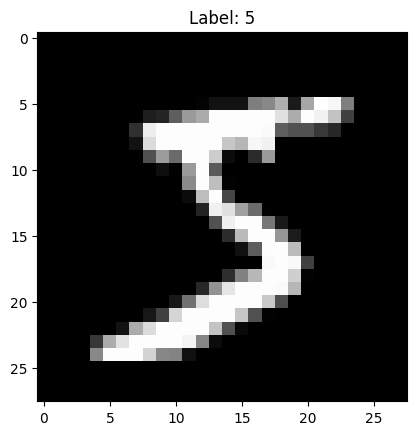

In [3]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Print dataset information
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)
print("Train labels:", train_labels)

# Display the first image
import matplotlib.pyplot as plt
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

### 1.6. Data Preprocessing

This section covers the steps required to prepare the data for training, including reshaping and normalizing the pixel values. Normalizing the pixel values to a range between 0 and 1 helps the model train faster and more effectively.

In [4]:
# Reshape the images to flatten them into vectors
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255


from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


print("Reshaped train images shape:", train_images.shape)
print("Reshaped test images shape:", test_images.shape)
print("Example train label (one-hot encoded):", train_labels[0])

Reshaped train images shape: (60000, 784)
Reshaped test images shape: (10000, 784)
Example train label (one-hot encoded): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 1.7. Creating a Validation Set

To properly evaluate our model during training and prevent overfitting, we'll create a validation set by splitting the training data. We'll use 10,000 images from the training set for validation and keep the remaining 50,000 for training.

In [5]:
# Creating a validation set
x_val = train_images[:10000]
partial_x_train = train_images[10000:]

y_val = train_labels[:10000]
partial_y_train = train_labels[10000:]

print("Partial training images shape:", partial_x_train.shape)
print("Validation images shape:", x_val.shape)
print("Partial training labels shape:", partial_y_train.shape)
print("Validation labels shape:", y_val.shape)

Partial training images shape: (50000, 784)
Validation images shape: (10000, 784)
Partial training labels shape: (50000, 10)
Validation labels shape: (10000, 10)


### 1.8. Addressing Potential Data Issues

While the MNIST dataset is relatively clean, it's important to consider potential issues that might arise in real-world datasets and how we would address them.

*   **Missing Data:** In the event of missing pixel values (which is unlikely in MNIST), we could consider techniques such as:
    *   **Mean/Median Imputation:** Replacing missing values with the mean or median pixel value across the dataset.
    *   **More Sophisticated Imputation:** Using machine learning models to predict missing values based on other features.

*   **Data Imbalance:** Although the class distribution in MNIST is relatively balanced, if we encountered a significant class imbalance (e.g., many more images of one digit than others), we could employ strategies such as:
    *   **Weighted Loss Functions:** Assigning higher weights to under-represented classes during training.
    *   **Oversampling:** Duplicating samples from under-represented classes.
    *   **Undersampling:** Removing samples from over-represented classes.

*   **Outliers:** While unlikely, outlier pixel values (e.g., extremely bright or dark pixels) could potentially affect model performance. We could consider:
    *   **Clipping:** Limiting pixel values to a specific range.
    *   **Robust Scaling:** Using scaling methods that are less sensitive to outliers (e.g., using quantiles).

These considerations ensure a more robust and adaptable approach to data preprocessing, even though they may not be strictly necessary for the MNIST dataset.